In [1]:
import csv
import pathlib
import pandas as pd

In [2]:
no_data_augmentation = "/mnt/eec07521-c36a-4d2b-9047-0110e7749eae/Nextcloud/Dropbox import/datasets/2025/uem/resultados/no-data-augmentation"
data_augmentation = "/mnt/eec07521-c36a-4d2b-9047-0110e7749eae/Nextcloud/Dropbox import/datasets/2025/uem/resultados/data-augmentation"

In [3]:
for p in pathlib.Path(no_data_augmentation).rglob("means+true_positive+sum.csv"):
    df = pd.read_csv(p, sep=";", header=0, index_col=None)
    display(df.head())

,label,specific_epithet,true_positive,true_positive_std,mean_test
0,1,Peperomia blanda,1.8,1.166190,5.0
1,2,Peperomia catharinae,2.0,0.632456,5.2
2,3,Peperomia corcovadensis,2.8,0.748331,6.2
3,4,Peperomia glabella,9.2,0.400000,10.0
4,5,Peperomia martiana,3.8,0.748331,6.0


In [4]:
df_no_data_aug = df.copy()
df_no_data_aug = df_no_data_aug.rename(columns={"true_positive": "no_data_augmentation_tp"})
df_no_data_aug = df_no_data_aug[["specific_epithet", "no_data_augmentation_tp", "mean_test"]]
df_no_data_aug.head()

,specific_epithet,no_data_augmentation_tp,mean_test
0,Peperomia blanda,1.8,5.0
1,Peperomia catharinae,2.0,5.2
2,Peperomia corcovadensis,2.8,6.2
3,Peperomia glabella,9.2,10.0
4,Peperomia martiana,3.8,6.0


In [5]:
import numpy as np
import matplotlib.pyplot as plt

def plot_comparative(data_aug_name, df):
    df = df.sort_values(by="mean_test", ascending=False).reset_index(drop=True)
    classes = df["specific_epithet"].tolist()
    total_amostras = df["mean_test"].values
    no_data_augmentation = df["no_data_augmentation_tp"].values
    data_aug = df[data_aug_name].values

    # Configurar eixo X
    x = np.arange(len(classes))
    largura = 0.25

    fig, ax = plt.subplots(figsize=(14, 6))

    # Barras
    ax.bar(x - largura, total_amostras, largura, label="Total amostras", color="gray")
    ax.bar(x, data_aug, largura, label=data_aug_name, color="skyblue")
    ax.bar(x + largura, no_data_augmentation, largura, label="No data augmentation", color="salmon")

    # Linha vermelha separando majoritárias/minoritárias (exemplo: na metade)
    ax.axvline(len(classes)//2, color="red", linestyle="--")

    # Textos indicativos
    ax.text(len(classes)//4, max(total_amostras)+2, "Classes majoritárias", ha="center")
    ax.text(3*len(classes)//4, max(total_amostras)+2, "Classes minoritárias", ha="center")

    # Configurações
    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=90, fontsize=8)
    ax.set_ylabel("Quantidade")
    ax.set_xlabel("Classes")
    ax.set_title("Figura – Análise da performance por classe")
    ax.legend()

    plt.tight_layout()
    plt.savefig("%s.png" % data_aug_name, dpi=300)
    plt.show()

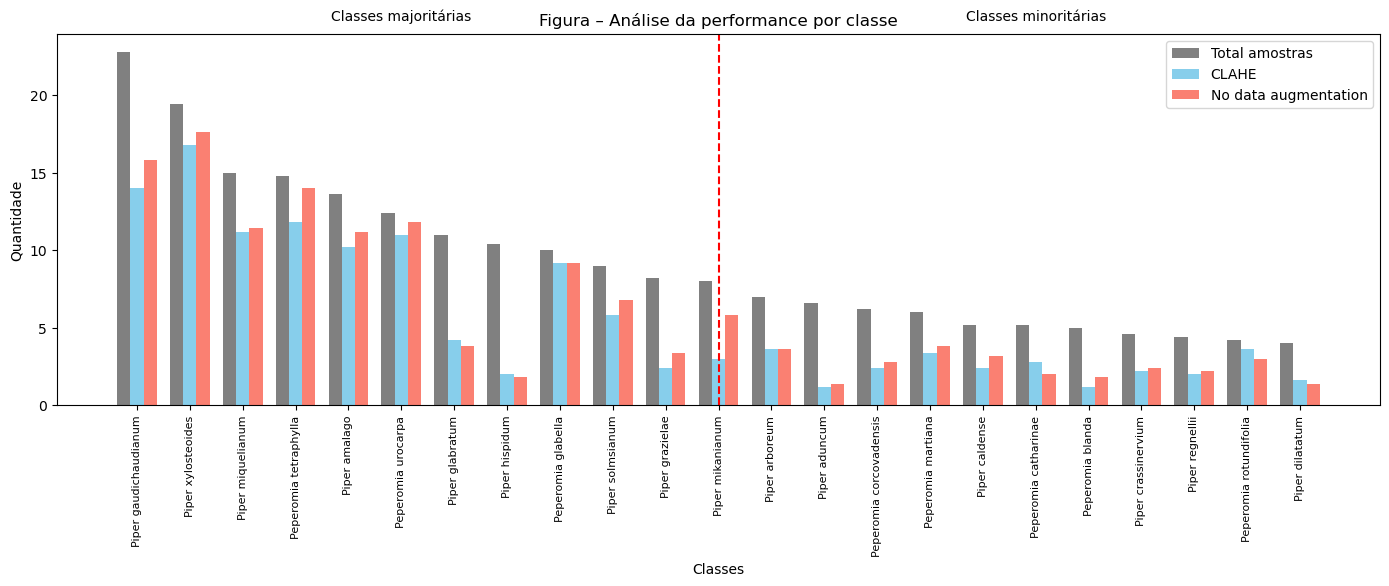

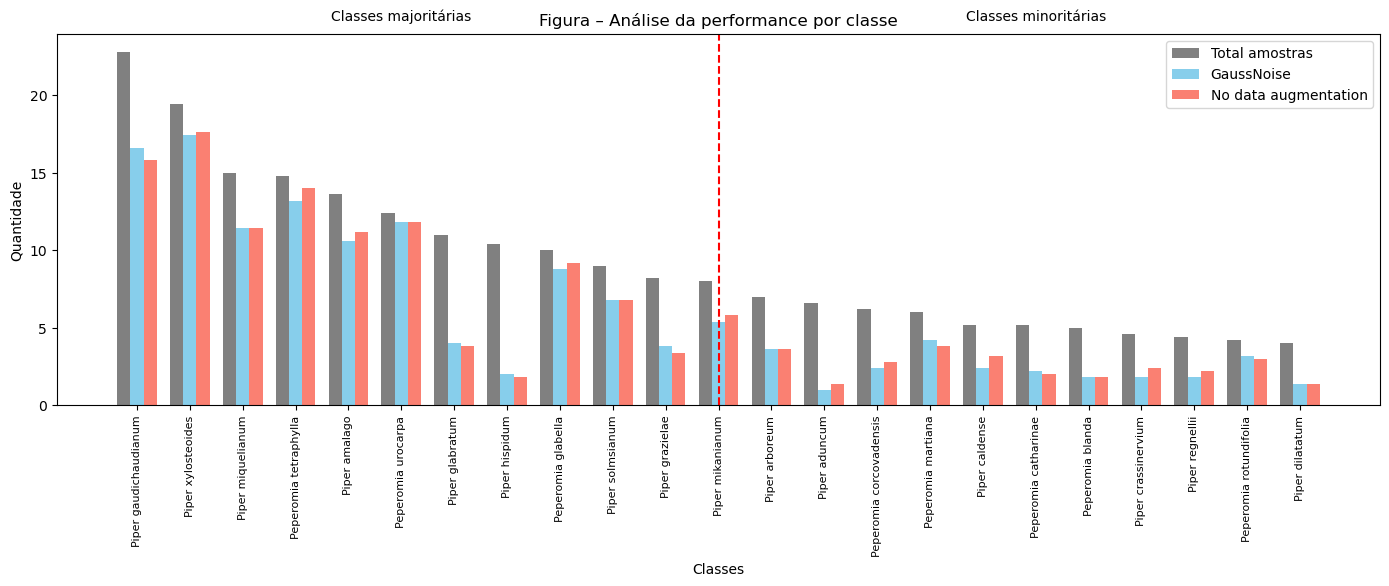

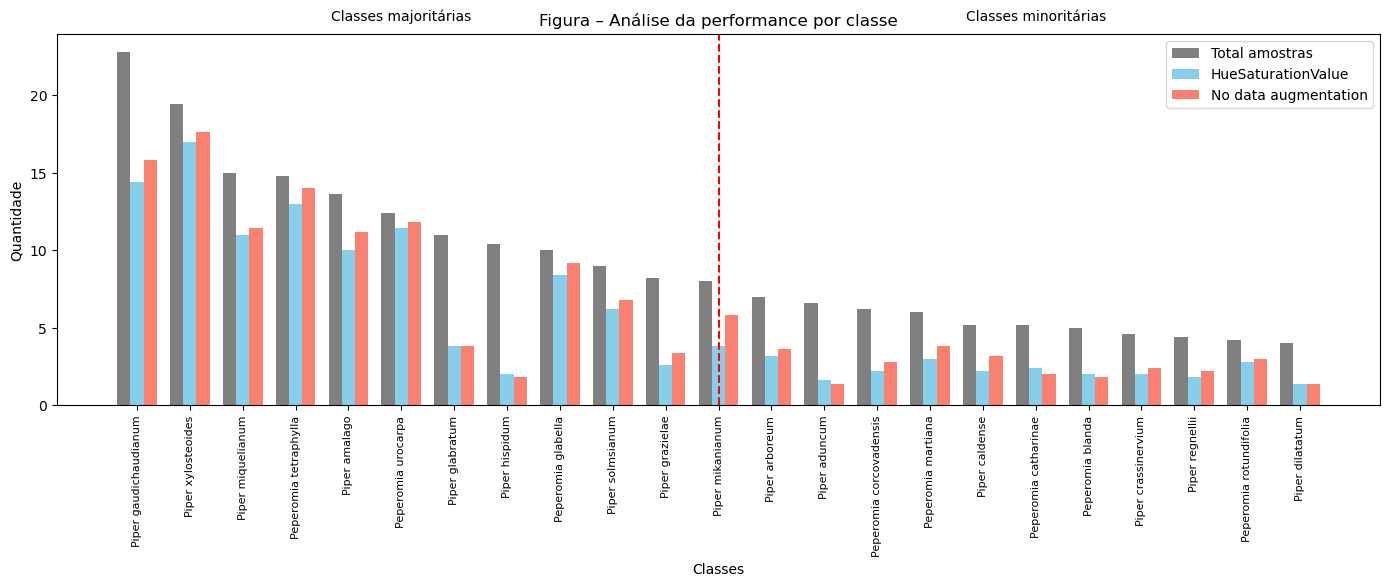

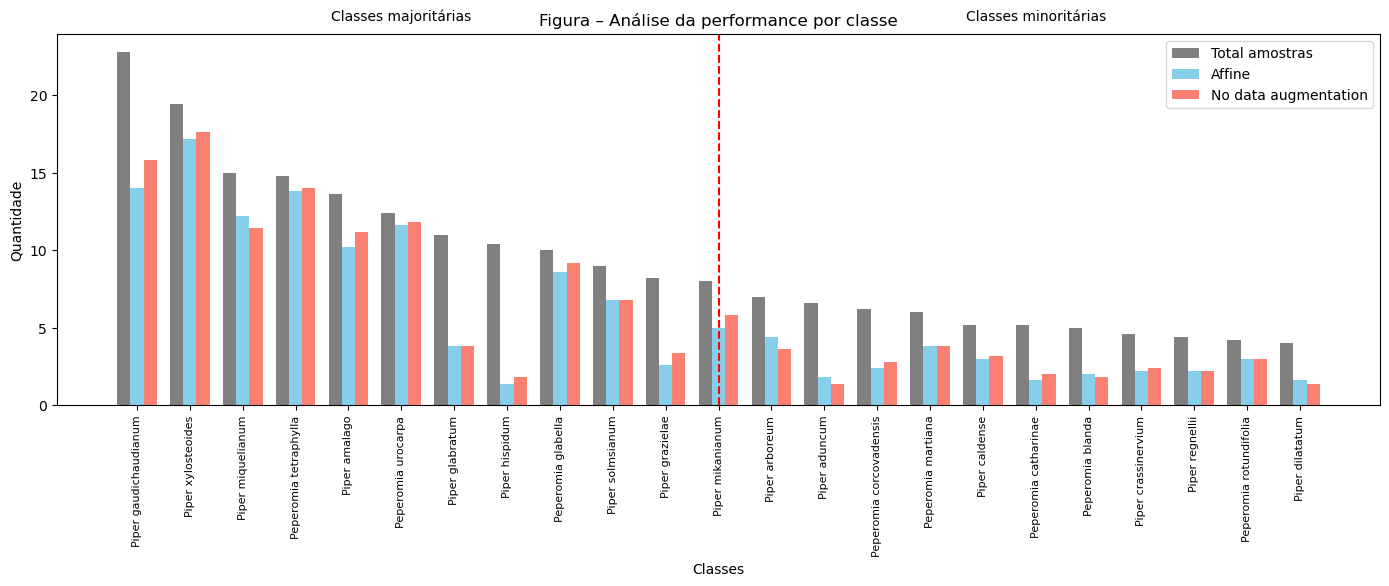

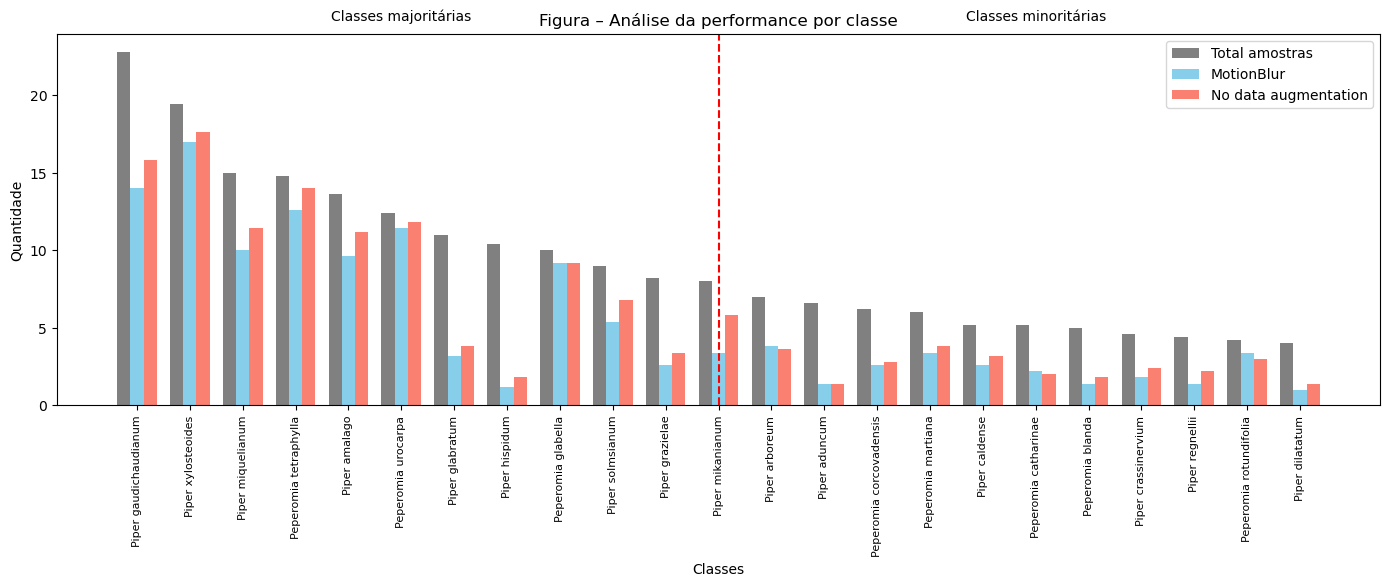

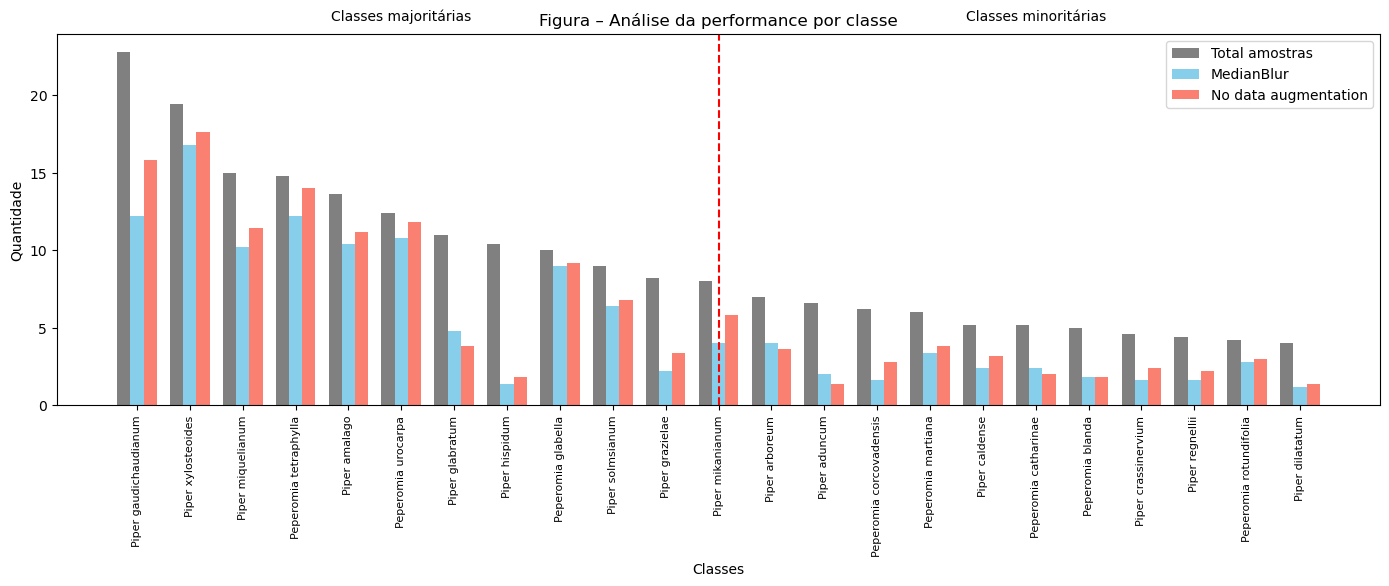

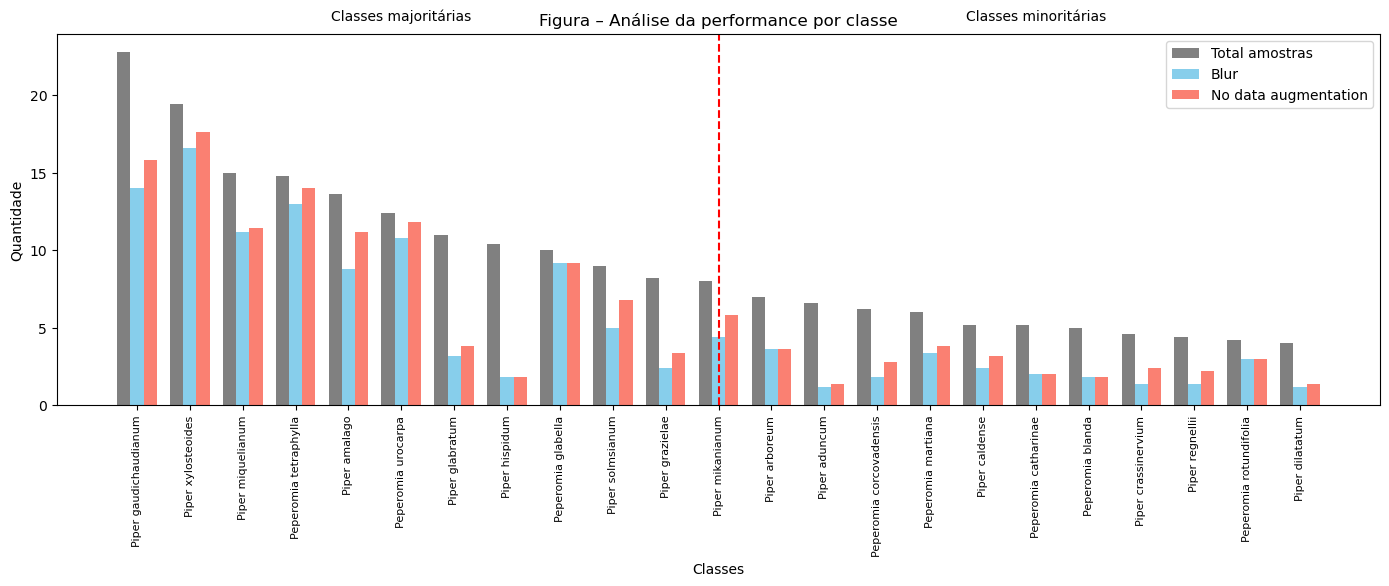

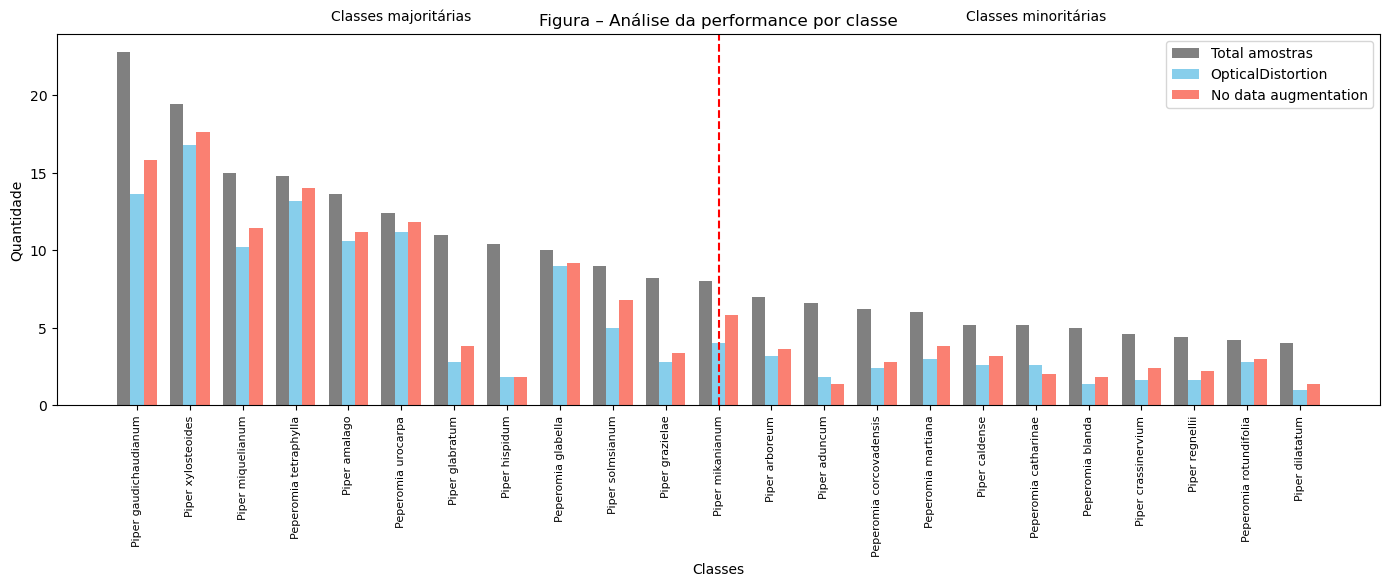

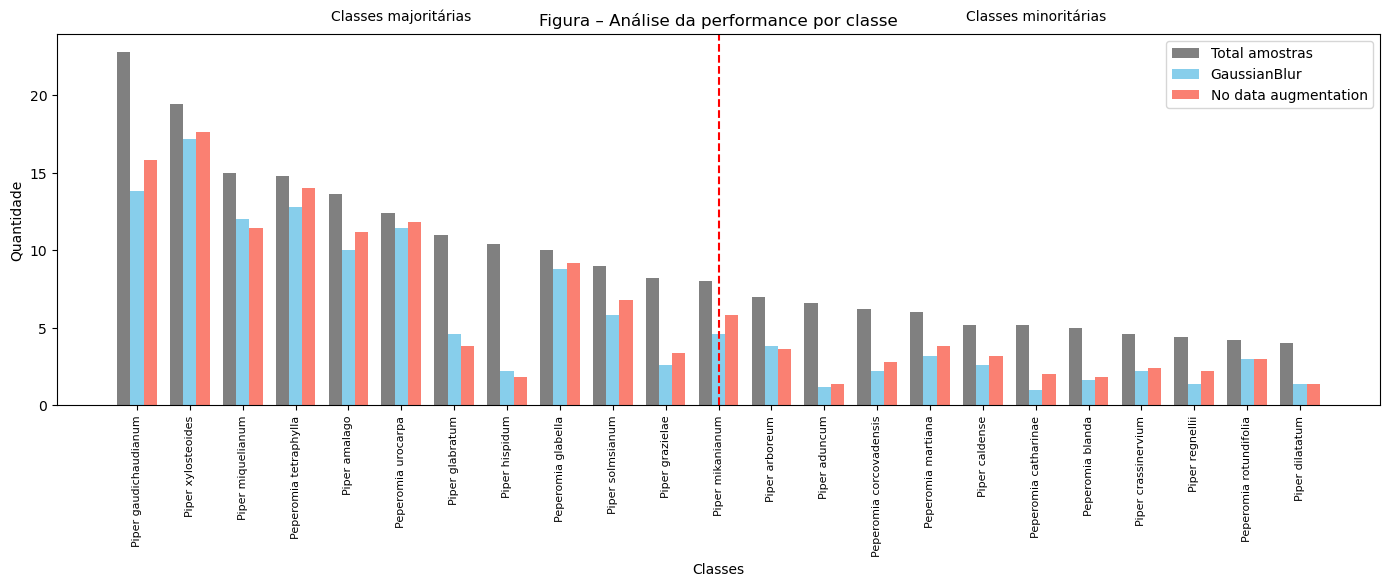

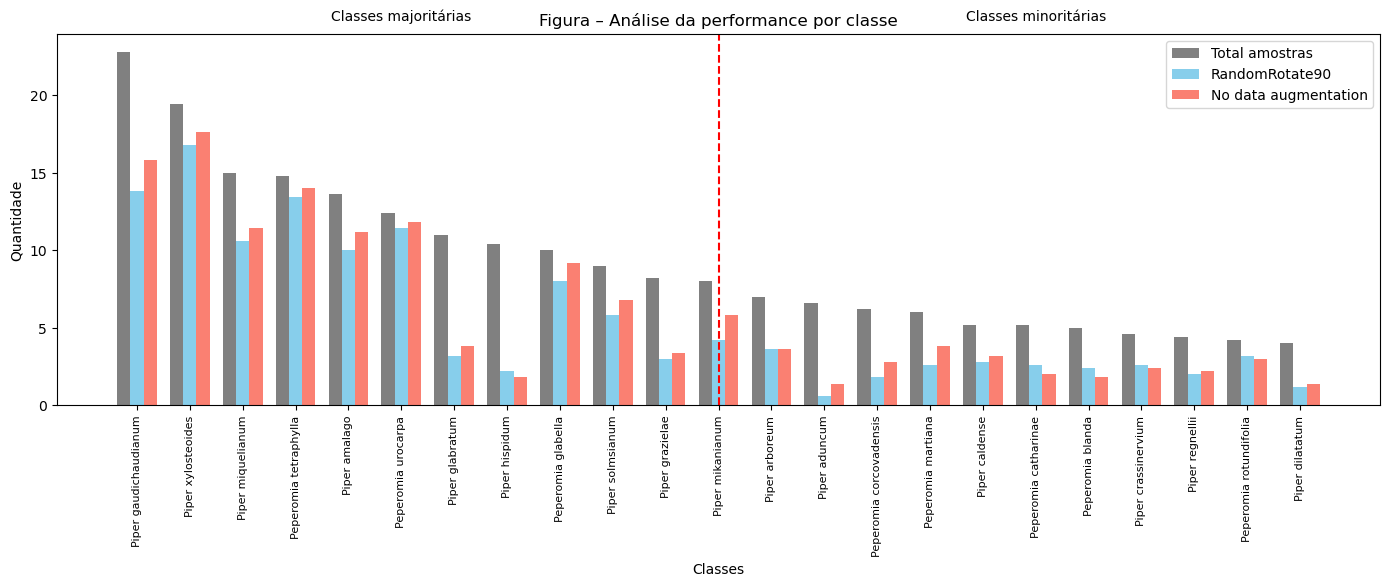

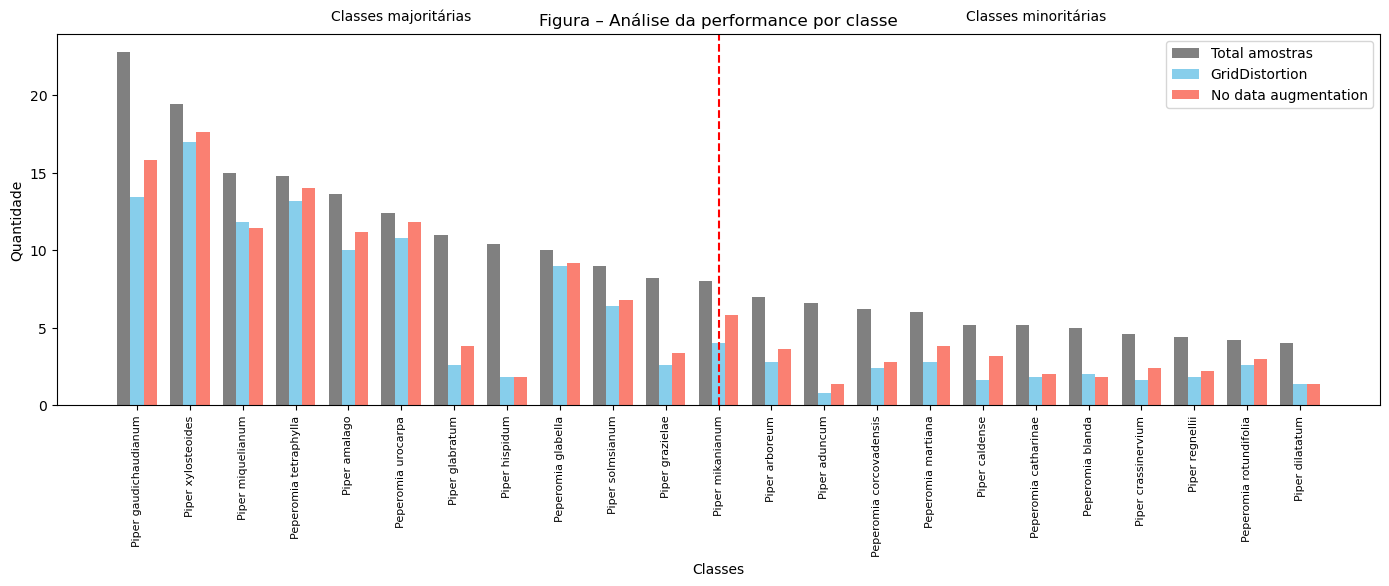

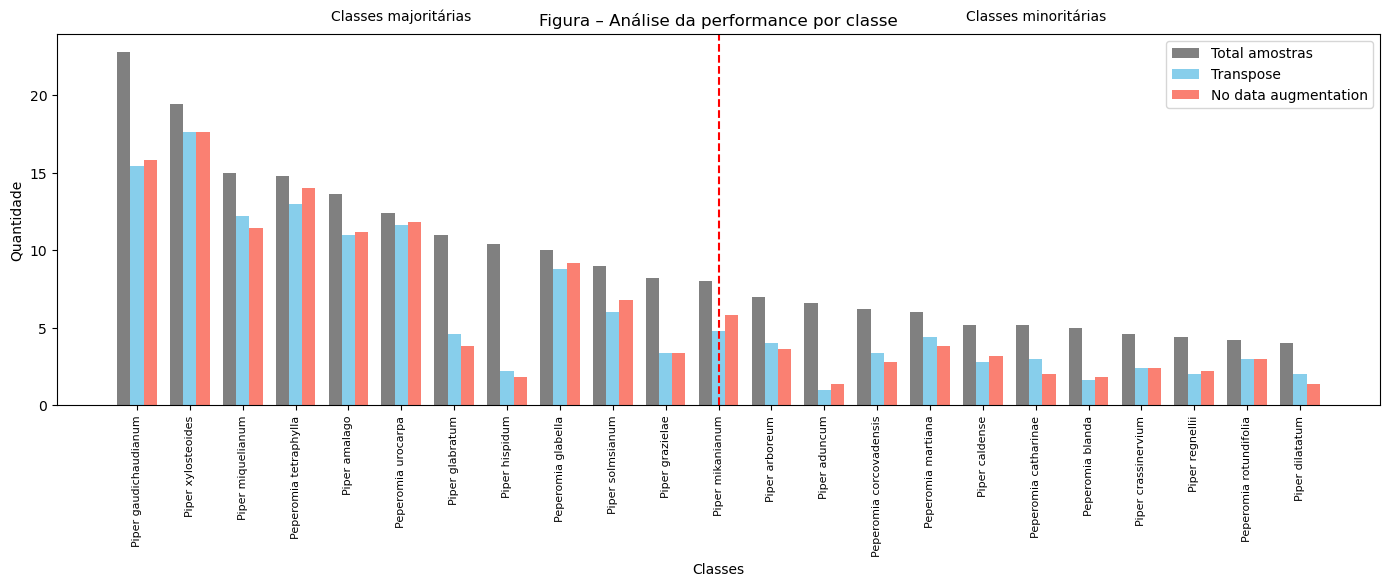

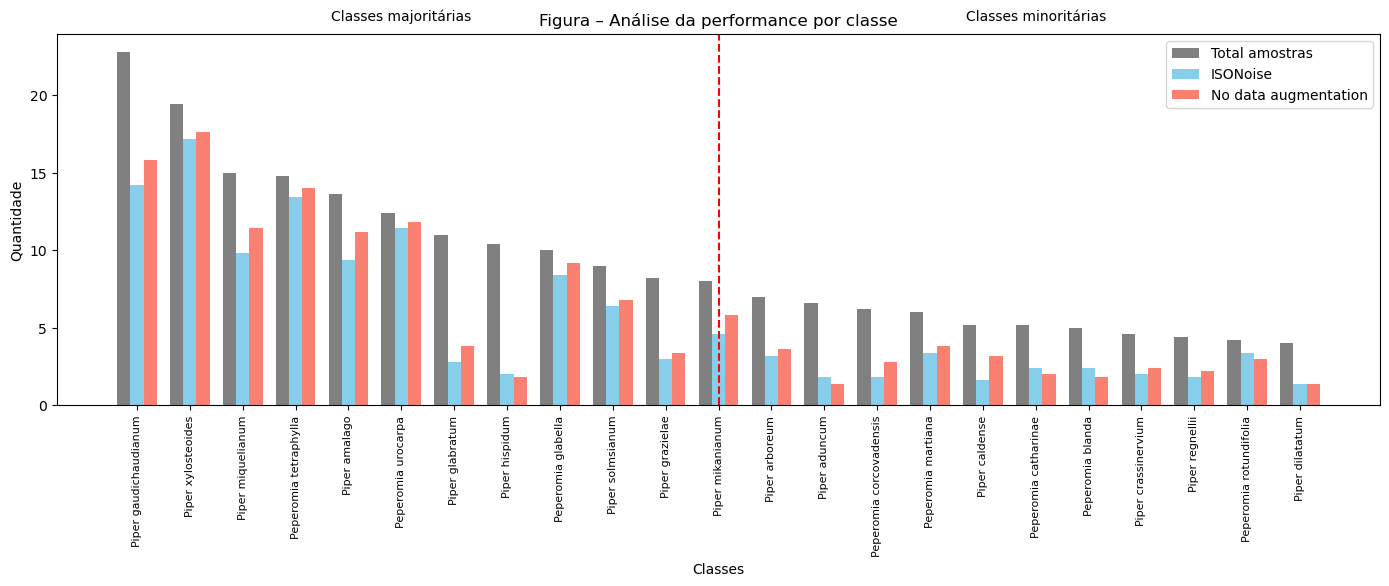

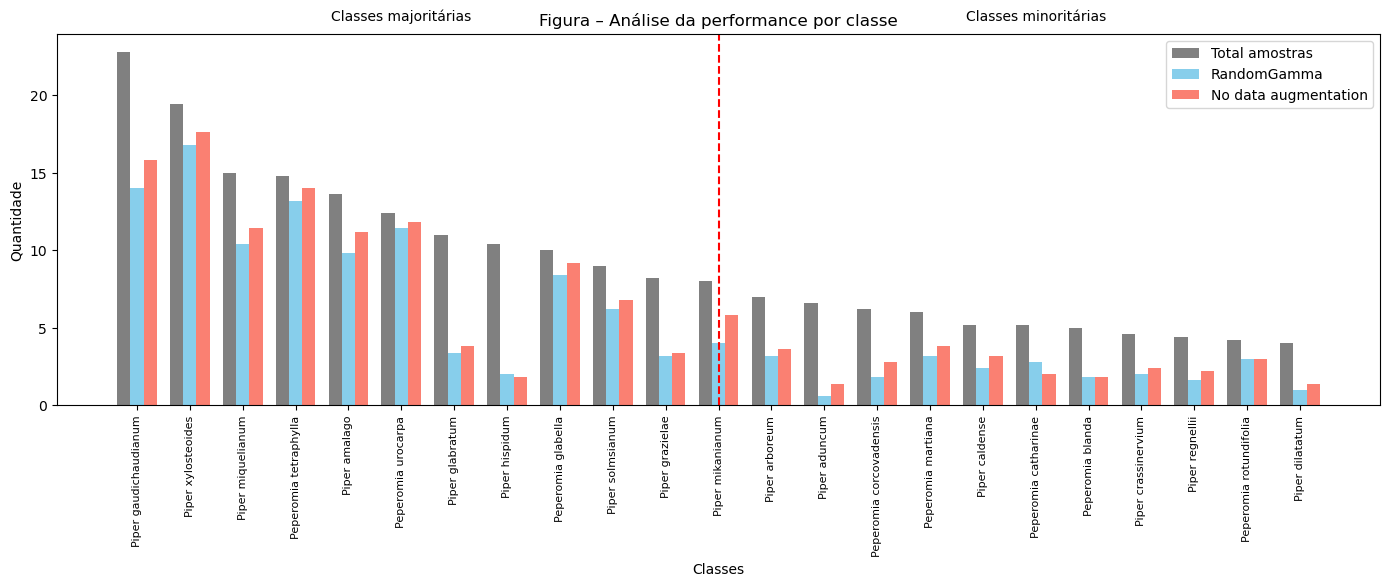

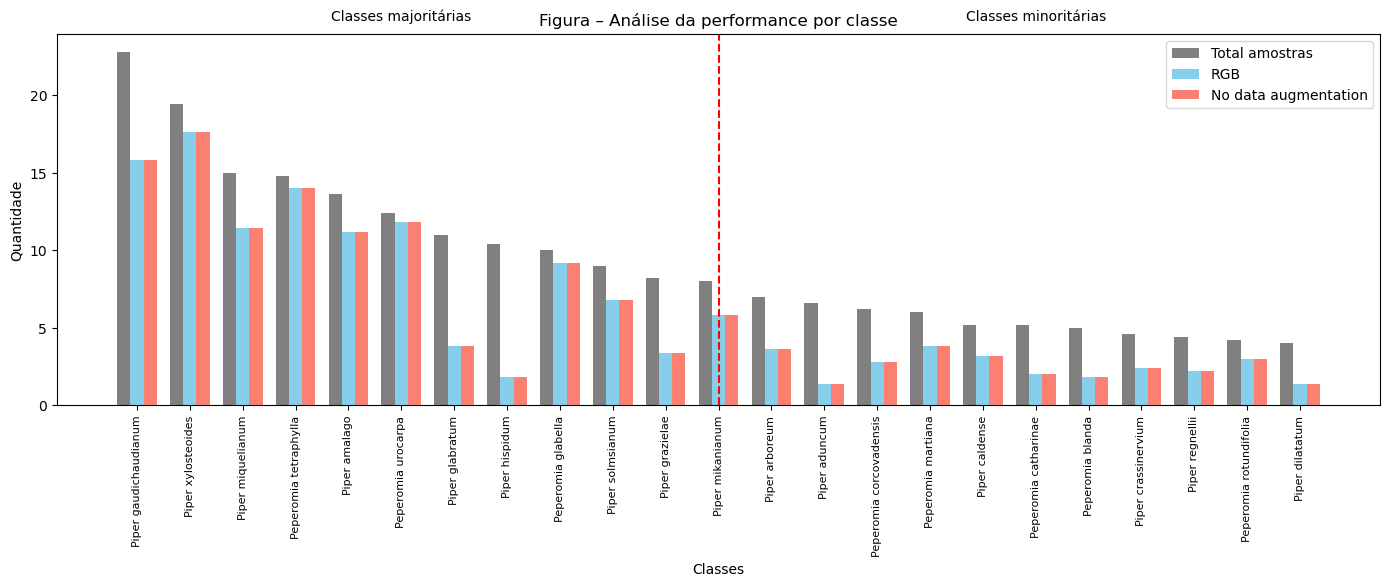

In [6]:
df_final = df_no_data_aug.copy()
for p in pathlib.Path(data_augmentation).rglob("means+true_positive+sum.csv"):
    df2 = pd.read_csv(p, sep=";", header=0, index_col=None)
    df2 = df2[["specific_epithet", "true_positive"]]
    df_comparative = pd.merge(df_no_data_aug, df2, on="specific_epithet")
    df_final = pd.merge(df_final, df2, on="specific_epithet")

    data_aug_name = p.parent.parent.parent.name.split("+")
    df_comparative = df_comparative.rename(columns={"true_positive": data_aug_name[2]})
    df_final = df_final.rename(columns={"true_positive": data_aug_name[2]})

    plot_comparative(data_aug_name[2], df_comparative)
df_final.to_csv("comparative.csv", index=False, sep=";", header=True, encoding="utf-8", quoting=2)